<a href="https://colab.research.google.com/github/65saimon/AponBazar/blob/main/Towhid_Diabetic_Retinopathy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetic Retinopathy Detection

Converted from the original Colab `.py` export into a runnable `.ipynb`. Sections follow the original notebook's flow: data loading, EDA, preprocessing, and training/evaluation of four models (VGG16+Attention, MobileNetV2+Attention, ResNet50, DenseNet121, EfficientNetB0).

## 1. Load dataset from Kaggle

In [ ]:
import kagglehub
pkdarabi_diagnosis_of_diabetic_retinopathy_path = kagglehub.dataset_download('pkdarabi/diagnosis-of-diabetic-retinopathy')

print('Data source import complete.')

100%|██████████| 30.1M/30.1M [00:00<00:00, 90.0MB/s]

Extracting files...


Data source import complete.


## 2. Imports & inspect the input directory

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## 3. Build the image/label dataframe

In [ ]:
base_path = "/kaggle/input/diagnosis-of-diabetic-retinopathy/retino/train"
categories = ["DR", "No_DR"]

base_path = os.path.join(pkdarabi_diagnosis_of_diabetic_retinopathy_path, 'retino', 'train')

image_paths = []
labels = []

for category in categories:
    category_path = os.path.join(base_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        image_paths.append(image_path)
        labels.append(category)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

## 4. Exploratory data analysis

In [ ]:
df.head()

df.tail()

df.shape

df.columns

df.duplicated().sum()

df.isnull().sum()

df.info()

df.nunique()

df['label'].unique()

df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2076 entries, 0 to 2075
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  2076 non-null   object
 1   label       2076 non-null   object
dtypes: object(2)
memory usage: 32.6+ KB


,count
label,
DR,1050
No_DR,1026


### Label distribution - count plot

/tmp/ipykernel_2141/2882839305.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="viridis")


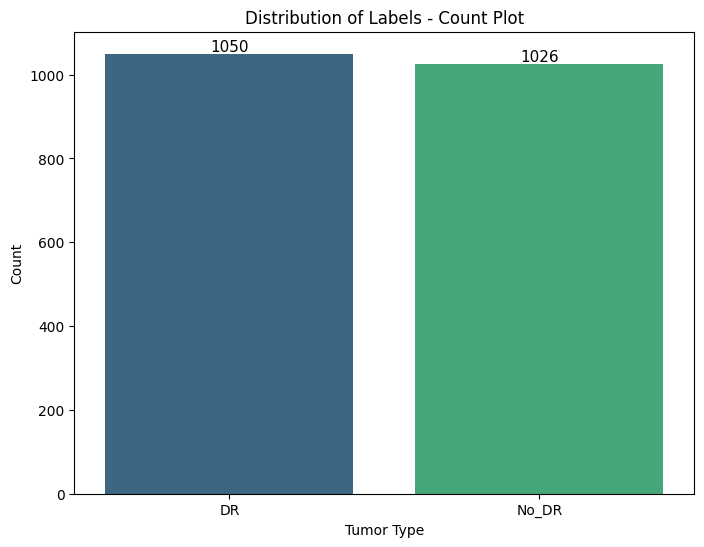

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="label", palette="viridis")
plt.title("Distribution of Labels - Count Plot")
plt.xlabel("Tumor Type")
plt.ylabel("Count")

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.show()

### Label distribution - pie chart

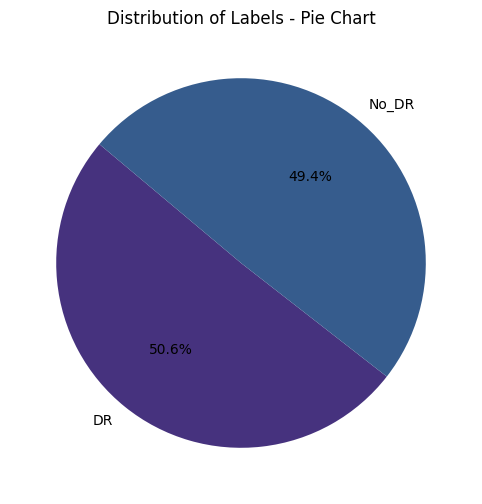

In [ ]:
label_counts = df['label'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis"))
plt.title("Distribution of Labels - Pie Chart")
plt.show()

### Sample images per class

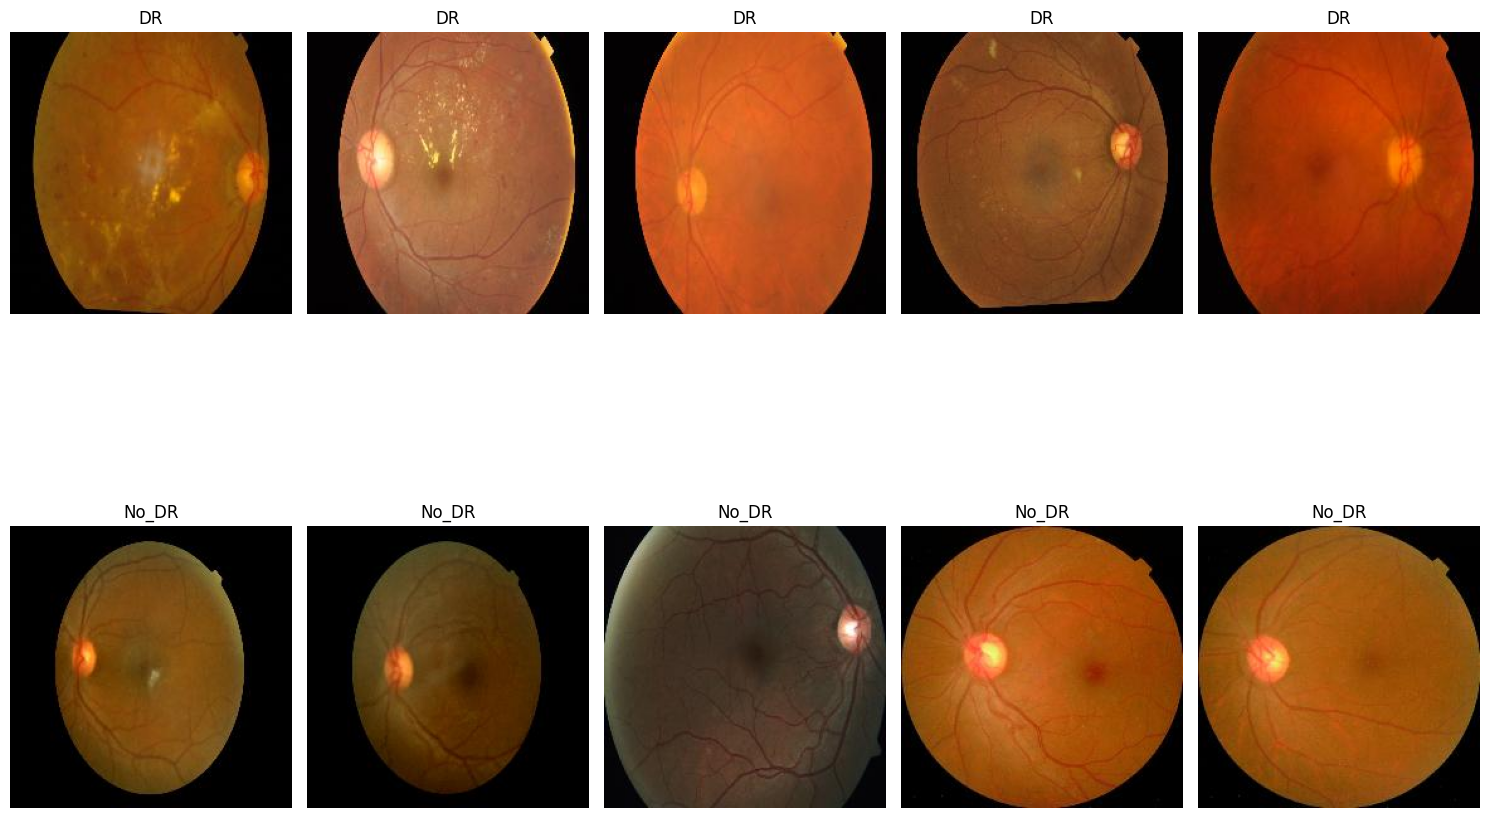

In [ ]:
import cv2

num_images = 5

plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df[df['label'] == category]['image_path'].iloc[:num_images]

    for j, img_path in enumerate(category_images):

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(category)

plt.tight_layout()
plt.show()

## 5. Preprocessing: encode labels & balance classes

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['category_encoded'] = label_encoder.fit_transform(df['label'])

df = df[['image_path', 'category_encoded']]

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(df[['image_path']], df['category_encoded'])

df_resampled = pd.DataFrame(X_resampled, columns=['image_path'])
df_resampled['category_encoded'] = y_resampled

print("\nClass distribution after oversampling:")
print(df_resampled['category_encoded'].value_counts())

df_resampled


Class distribution after oversampling:
category_encoded
0    1050
1    1050
Name: count, dtype: int64


,image_path,category_encoded
0,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,0
1,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,0
2,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,0
3,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,0
4,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,0
...,...,...
2095,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,1
2096,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,1
2097,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,1
2098,/root/.cache/kagglehub/datasets/pkdarabi/diagn...,1


## 6. Modeling imports & train/val/test split

In [ ]:
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('check')

check


In [ ]:
df_resampled['category_encoded'] = df_resampled['category_encoded'].astype(str)

train_df_new, temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=df_resampled['category_encoded']
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['category_encoded']
)

## 7. Image data generators

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='image_path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 1680 validated image filenames belonging to 2 classes.
Found 210 validated image filenames belonging to 2 classes.
Found 210 validated image filenames belonging to 2 classes.


## 8. GPU check & shared callbacks

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("Using GPU")
else:
    print("Using CPU")

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Using GPU


## 9. Model 1: VGG16 backbone + Multi-Head Attention

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, GaussianNoise,
                                     Input, MultiHeadAttention, Reshape)
from tensorflow.keras.optimizers import Adam

def create_vgg16_model(input_shape):
    inputs = Input(shape=input_shape)

    base_model = VGG16(weights='imagenet', input_tensor=inputs, include_top=False)

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output

    height, width, channels = 7, 7, 512
    x = Reshape((height * width, channels))(x)

    attention_output = MultiHeadAttention(num_heads=8, key_dim=channels)(x, x)
    attention_output = Reshape((height, width, channels))(attention_output)

    x = GaussianNoise(0.25)(attention_output)

    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation='relu')(x)
    x = GaussianNoise(0.25)(x)
    x = Dropout(0.25)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)

    return model

In [ ]:
input_shape = (224, 224, 3)

cnn_model = create_vgg16_model(input_shape)

cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

import time

start_time = time.time()
history = cnn_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)
end_time = time.time()

inference_time = end_time - start_time
print(f"Inference time: {inference_time:.4f} seconds")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 33s 160ms/step - accuracy: 0.8321 - loss: 0.3756 - val_accuracy: 0.8857 - val_loss: 0.2945
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.9113 - loss: 0.2485 - val_accuracy: 0.9095 - val_loss: 0.2777
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - accuracy: 0.9298 - loss: 0.2081 - val_accuracy: 0.8857 - val_loss: 0.2474
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.9339 - loss: 0.1961 - val_accuracy: 0.8905 - val_loss: 0.2474
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.9310 - loss: 0.1889 - val_accuracy: 0.9143 - val_loss: 0.2134
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - accuracy: 0.9423 - loss: 0.1746 - val_accuracy: 0.8952 - val_loss: 0.2147
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.9452 - loss: 0.1573 - val_accuracy: 0.9190 - val_loss: 0.2146
Epoch 8/20
105/105 ━━━━━━━━━━━━━

### Training curves & evaluation - VGG16 + Attention

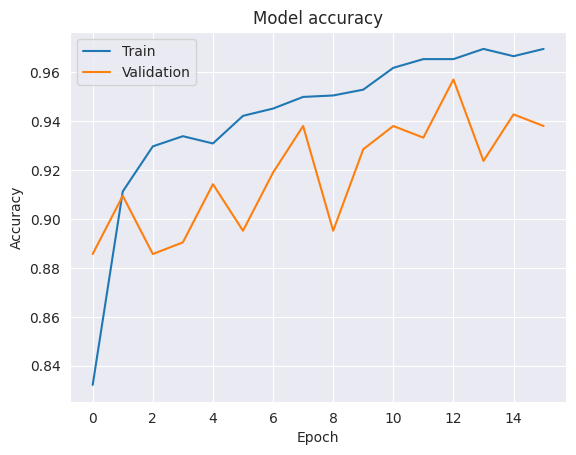

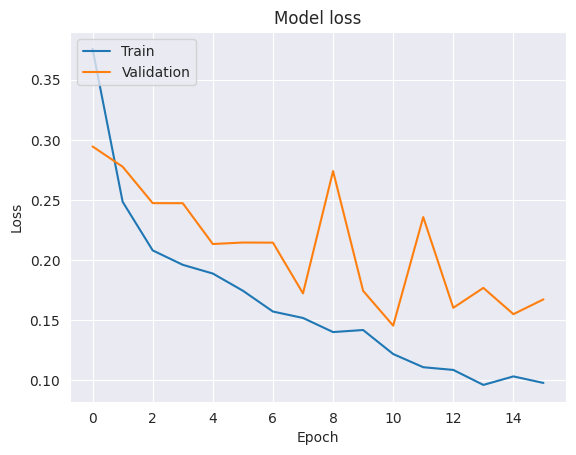

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step
Quadratic Weighted Kappa (QWK): 0.9143
Accuracy : 0.9571
QWK      : 0.9143

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       105
           1       0.97      0.94      0.96       105

    accuracy                           0.96       210
   macro avg       0.96      0.96      0.96       210
weighted avg       0.96      0.96      0.96       210



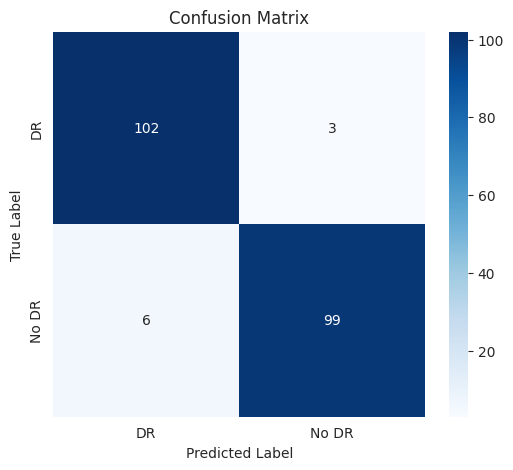

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

test_labels = test_gen_new.classes
predictions = cnn_model.predict(test_gen_new)
predicted_labels = (predictions > 0.5).astype(int).flatten()

from sklearn.metrics import cohen_kappa_score

# Quadratic Weighted Kappa (QWK)
qwk = cohen_kappa_score(
    test_labels,
    predicted_labels,
    weights='quadratic'
)

print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")

from sklearn.metrics import classification_report, accuracy_score, cohen_kappa_score

acc = accuracy_score(test_labels, predicted_labels)
qwk = cohen_kappa_score(test_labels, predicted_labels, weights='quadratic')

print(f"Accuracy : {acc:.4f}")
print(f"QWK      : {qwk:.4f}\n")

report = classification_report(
    test_labels,
    predicted_labels,
    target_names=list(test_gen_new.class_indices.keys())
)
print(report)

conf_matrix = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['DR', 'No DR'], yticklabels=['DR', 'No DR'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 10. Model 2: MobileNetV2 backbone (lightweight) + Multi-Head Attention

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, GaussianNoise,
                                     Input, MultiHeadAttention, Reshape)
from tensorflow.keras.optimizers import Adam

def create_lightweight_model(input_shape):
    inputs = Input(shape=input_shape)
    base_model = MobileNetV2(weights='imagenet', input_tensor=inputs, include_top=False)
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    height, width, channels = x.shape[1], x.shape[2], x.shape[3]
    x = Reshape((height * width, channels))(x)
    attention_output = MultiHeadAttention(num_heads=4, key_dim=channels)(x, x)
    attention_output = Reshape((height, width, channels))(attention_output)
    x = GaussianNoise(0.2)(attention_output)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = GaussianNoise(0.2)(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model

input_shape = (224, 224, 3)
cnn_model = create_lightweight_model(input_shape)
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import time

start_time = time.time()
history = cnn_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)
end_time = time.time()

inference_time = end_time - start_time
print(f"Inference time: {inference_time:.4f} seconds")

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 50s 239ms/step - accuracy: 0.9280 - loss: 0.2085 - val_accuracy: 0.9524 - val_loss: 0.1399
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9667 - loss: 0.1162 - val_accuracy: 0.9619 - val_loss: 0.1082
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.9720 - loss: 0.0815 - val_accuracy: 0.9286 - val_loss: 0.4361
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.9685 - loss: 0.0872 - val_accuracy: 0.9571 - val_loss: 0.1006
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9786 - loss: 0.0607 - val_accuracy: 0.9381 - val_loss: 0.1576
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9720 - loss: 0.0876 - val_accuracy: 0.9667 - val_loss: 0.1500
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.9833 - loss: 0.0490 - val_accuracy: 0.9571 - val_loss: 0.2115
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.9964 - loss: 0.0132 - val_ac

### Training curves & evaluation - MobileNetV2 + Attention

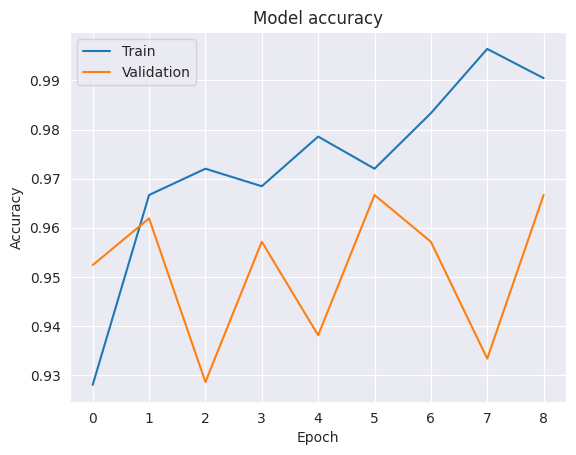

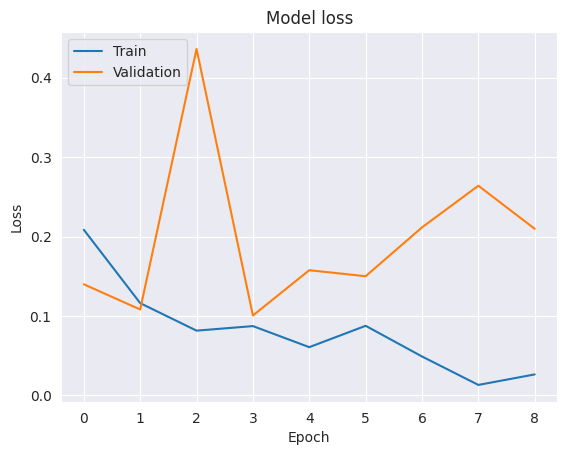

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 381ms/step
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       105
           1       0.96      0.93      0.95       105

    accuracy                           0.95       210
   macro avg       0.95      0.95      0.95       210
weighted avg       0.95      0.95      0.95       210



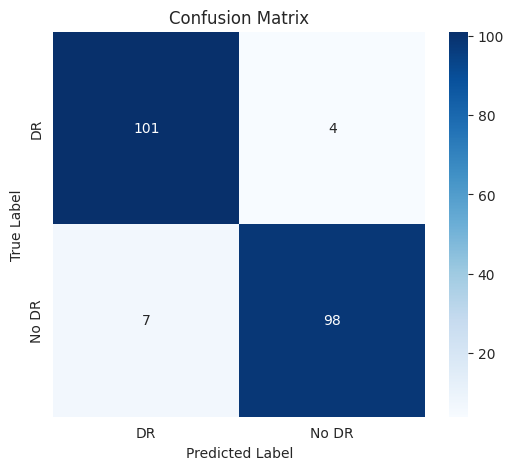

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

test_labels = test_gen_new.classes
predictions = cnn_model.predict(test_gen_new)
predicted_labels = (predictions > 0.5).astype(int).flatten()

from sklearn.metrics import classification_report

report = classification_report(test_labels, predicted_labels, target_names=list(test_gen_new.class_indices.keys()))
print(report)

conf_matrix = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['DR', 'No DR'], yticklabels=['DR', 'No DR'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 11. Model 2 (repeat run)

**Note:** the original notebook re-defines and re-trains the same MobileNetV2 + Attention model a second time here (this duplication was already present in the source `.py`). Kept as-is for fidelity — feel free to delete this cell block if you don't need the repeat run.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, GaussianNoise,
                                     Input, MultiHeadAttention, Reshape)
from tensorflow.keras.optimizers import Adam

def create_lightweight_model(input_shape):
    inputs = Input(shape=input_shape)
    base_model = MobileNetV2(weights='imagenet', input_tensor=inputs, include_top=False)
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    height, width, channels = x.shape[1], x.shape[2], x.shape[3]
    x = Reshape((height * width, channels))(x)
    attention_output = MultiHeadAttention(num_heads=4, key_dim=channels)(x, x)
    attention_output = Reshape((height, width, channels))(attention_output)
    x = GaussianNoise(0.2)(attention_output)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = GaussianNoise(0.2)(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model

input_shape = (224, 224, 3)
cnn_model = create_lightweight_model(input_shape)
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

import time

start_time = time.time()
history = cnn_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=5,
    callbacks=[early_stopping],
    verbose=1
)
end_time = time.time()

inference_time = end_time - start_time
print(f"Inference time: {inference_time:.4f} seconds")

Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 32s 162ms/step - accuracy: 0.9185 - loss: 0.2083 - val_accuracy: 0.9000 - val_loss: 0.2301
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.9595 - loss: 0.1306 - val_accuracy: 0.9714 - val_loss: 0.1439
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.9696 - loss: 0.0980 - val_accuracy: 0.9619 - val_loss: 0.0988
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.9744 - loss: 0.0855 - val_accuracy: 0.9190 - val_loss: 0.2726
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.9738 - loss: 0.0782 - val_accuracy: 0.9476 - val_loss: 0.1809
Inference time: 62.9723 seconds


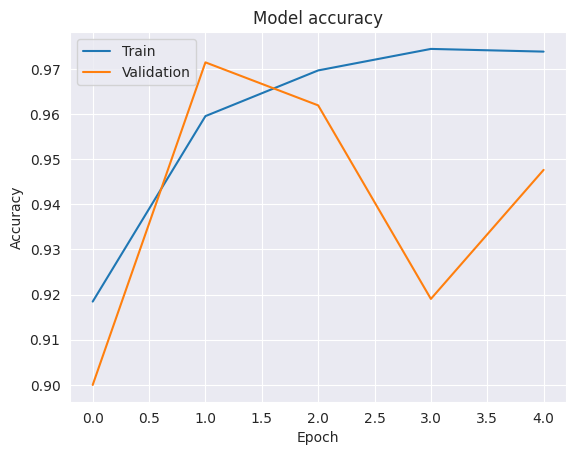

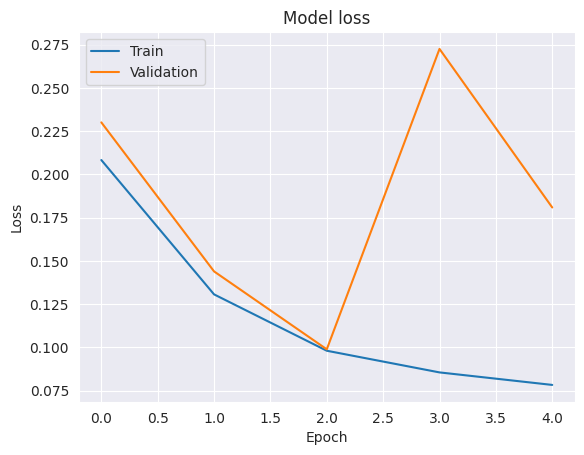

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 383ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       105
           1       0.98      0.98      0.98       105

    accuracy                           0.98       210
   macro avg       0.98      0.98      0.98       210
weighted avg       0.98      0.98      0.98       210



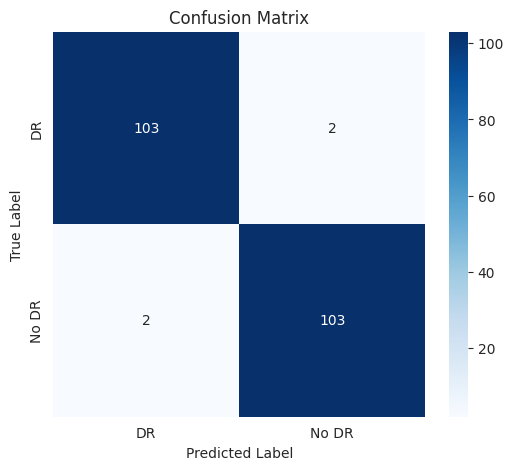

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

test_labels = test_gen_new.classes
predictions = cnn_model.predict(test_gen_new)
predicted_labels = (predictions > 0.5).astype(int).flatten()

from sklearn.metrics import classification_report

report = classification_report(test_labels, predicted_labels, target_names=list(test_gen_new.class_indices.keys()))
print(report)

conf_matrix = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['DR', 'No DR'], yticklabels=['DR', 'No DR'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 12. Additional Model 1: ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50, DenseNet121, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score


def plot_model_history(history, model_name):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')
    plt.show()


def evaluate_image_model(model, model_name):
    test_gen_new.reset()
    predictions = model.predict(test_gen_new)
    predicted_labels = (predictions > 0.5).astype(int).flatten()
    test_labels = test_gen_new.classes

    acc = accuracy_score(test_labels, predicted_labels)
    qwk = cohen_kappa_score(test_labels, predicted_labels, weights='quadratic')

    print(f'\n{model_name} Results')
    print(f'Accuracy : {acc:.4f}')
    print(f'QWK      : {qwk:.4f}\n')
    print(classification_report(
        test_labels,
        predicted_labels,
        target_names=list(test_gen_new.class_indices.keys())
    ))

    conf_matrix = confusion_matrix(test_labels, predicted_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=list(test_gen_new.class_indices.keys()),
        yticklabels=list(test_gen_new.class_indices.keys())
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    return predictions, predicted_labels, acc, qwk


def create_transfer_model(base_model_class, input_shape, dense_units=256, dropout_rate=0.3):
    inputs = Input(shape=input_shape)
    base_model = base_model_class(weights='imagenet', include_top=False, input_tensor=inputs)

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 171ms/step - accuracy: 0.8351 - loss: 0.4284 - val_accuracy: 0.5000 - val_loss: 0.8025
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.8815 - loss: 0.2870 - val_accuracy: 0.5000 - val_loss: 0.7123
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.8970 - loss: 0.2572 - val_accuracy: 0.6048 - val_loss: 0.5501
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.8958 - loss: 0.2493 - val_accuracy: 0.8762 - val_loss: 0.3980
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.8988 - loss: 0.2463 - val_accuracy: 0.9000 - val_loss: 0.2916
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.9083 - loss: 0.2243 - val_accuracy: 0.8905 - val_loss: 0.2399
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9101 - loss: 0.2303 - val_accuracy: 0.8857 - val_loss: 0.2224
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 

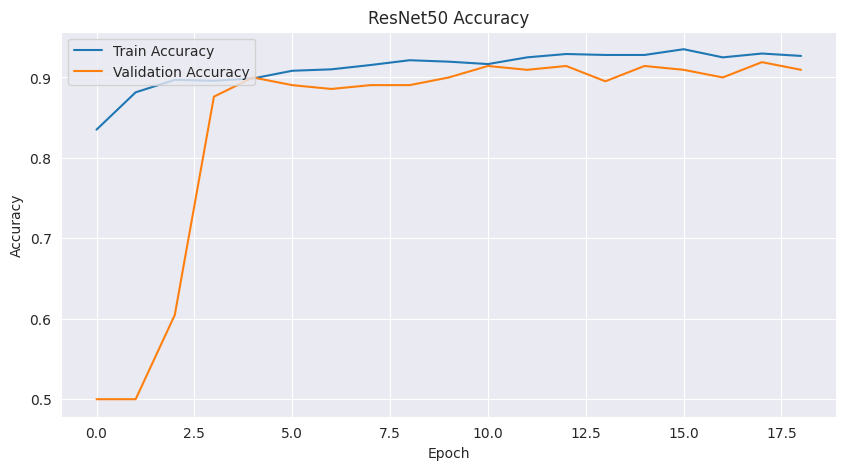

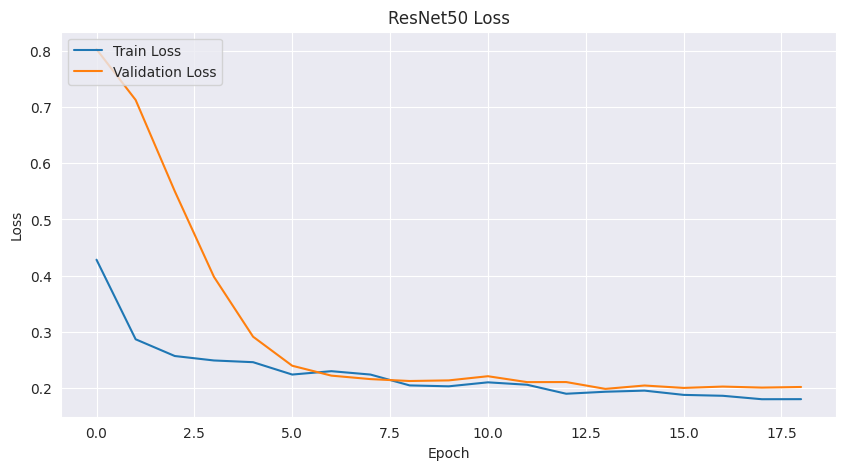

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 340ms/step

ResNet50 Results
Accuracy : 0.9095
QWK      : 0.8190

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       105
           1       0.92      0.90      0.91       105

    accuracy                           0.91       210
   macro avg       0.91      0.91      0.91       210
weighted avg       0.91      0.91      0.91       210



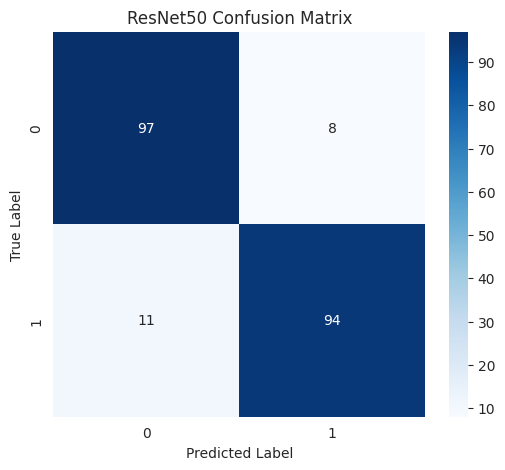

In [ ]:
input_shape = (224, 224, 3)

resnet50_model = create_transfer_model(ResNet50, input_shape, dense_units=256, dropout_rate=0.3)
resnet50_history = resnet50_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=20,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
plot_model_history(resnet50_history, 'ResNet50')
resnet50_predictions, resnet50_predicted_labels, resnet50_acc, resnet50_qwk = evaluate_image_model(resnet50_model, 'ResNet50')

## 13. Additional Model 2: DenseNet121

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 58s 296ms/step - accuracy: 0.8917 - loss: 0.2793 - val_accuracy: 0.8810 - val_loss: 0.3376
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9351 - loss: 0.1861 - val_accuracy: 0.9381 - val_loss: 0.2411
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.9524 - loss: 0.1518 - val_accuracy: 0.9524 - val_loss: 0.1967
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9613 - loss: 0.1200 - val_accuracy: 0.9476 - val_loss: 0.1729
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9536 - loss: 0.1278 - val_accuracy: 0.9476 - val_loss: 0.1522
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9637 - loss: 0.1117 - val_accuracy: 0.9476 - val_loss: 0.1404
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.9685 - loss: 0.1015 - val_accuracy: 0.9571 - val_loss: 0.1305
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 5

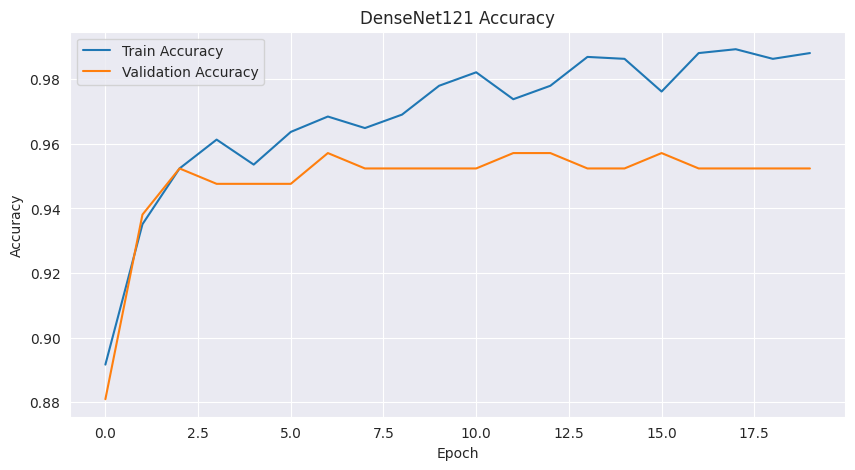

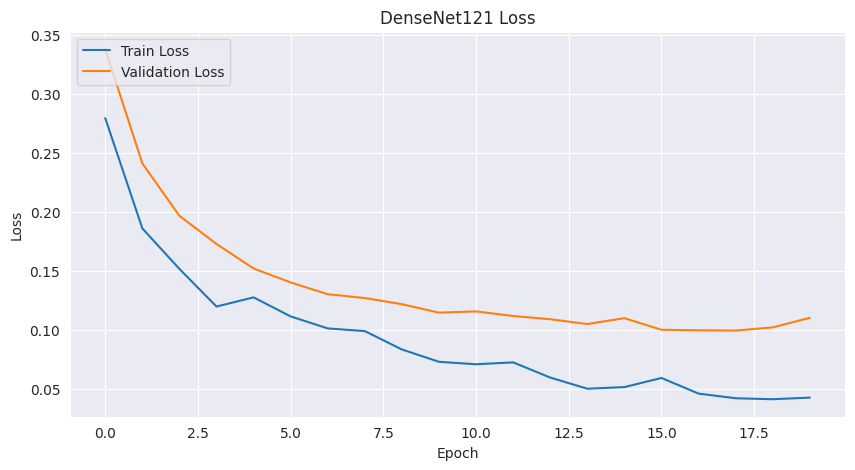

14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step

DenseNet121 Results
Accuracy : 0.9667
QWK      : 0.9333

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       105
           1       0.96      0.97      0.97       105

    accuracy                           0.97       210
   macro avg       0.97      0.97      0.97       210
weighted avg       0.97      0.97      0.97       210



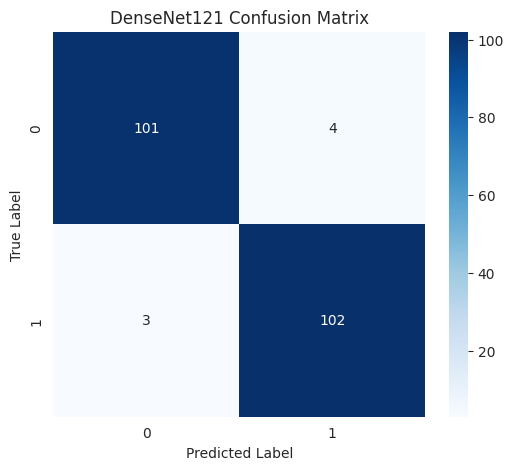

In [ ]:
densenet121_model = create_transfer_model(DenseNet121, input_shape, dense_units=256, dropout_rate=0.3)
densenet121_history = densenet121_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=20,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
plot_model_history(densenet121_history, 'DenseNet121')
densenet121_predictions, densenet121_predicted_labels, densenet121_acc, densenet121_qwk = evaluate_image_model(densenet121_model, 'DenseNet121')

## 14. Additional Model 3: EfficientNetB0

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 44s 178ms/step - accuracy: 0.4929 - loss: 0.7355 - val_accuracy: 0.5000 - val_loss: 0.7005
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4875 - loss: 0.7370 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4935 - loss: 0.7369 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5077 - loss: 0.7267 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4988 - loss: 0.7303 - val_accuracy: 0.4905 - val_loss: 0.6925
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5196 - loss: 0.7225 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5208 - loss: 0.7235 - val_accuracy: 0.5048 - val_loss: 0.6910
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 2

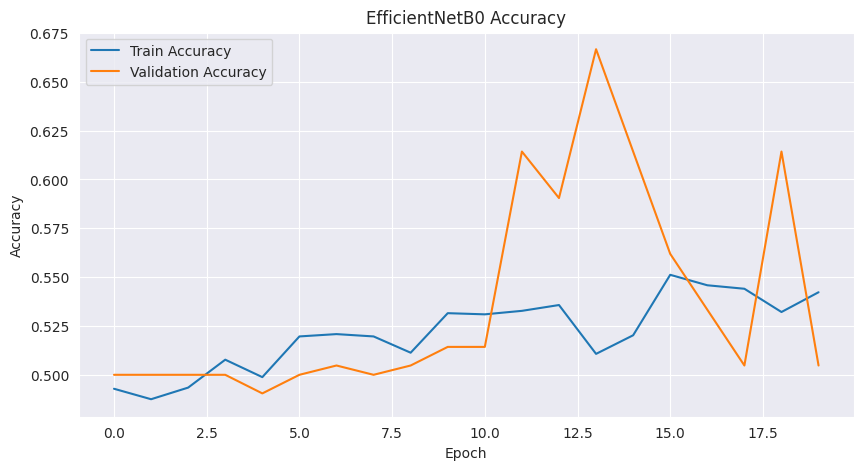

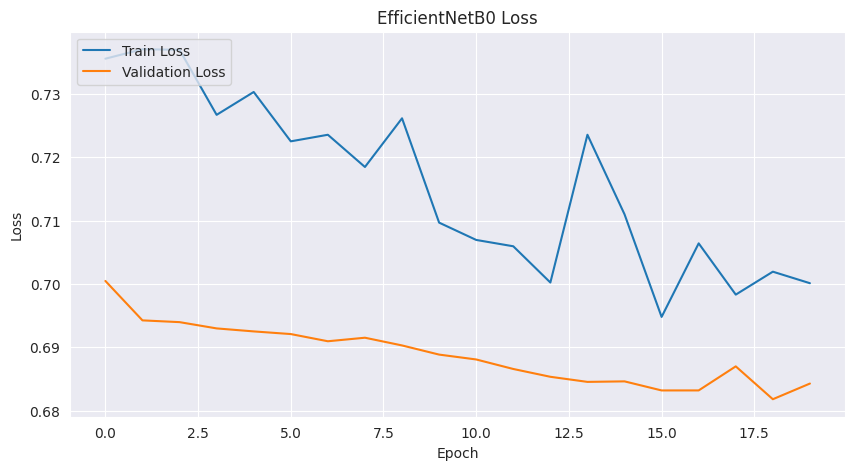

14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 568ms/step

EfficientNetB0 Results
Accuracy : 0.6381
QWK      : 0.2762

              precision    recall  f1-score   support

           0       1.00      0.28      0.43       105
           1       0.58      1.00      0.73       105

    accuracy                           0.64       210
   macro avg       0.79      0.64      0.58       210
weighted avg       0.79      0.64      0.58       210



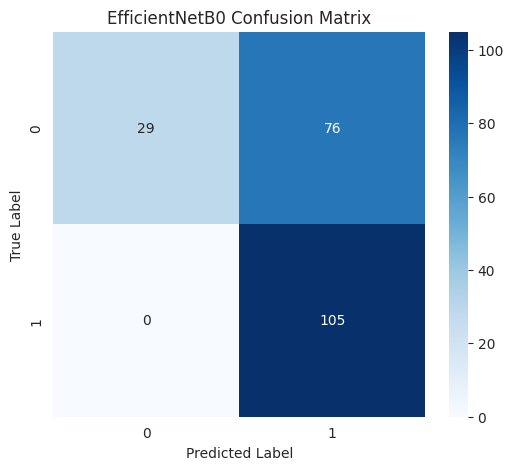

In [ ]:
efficientnetb0_model = create_transfer_model(EfficientNetB0, input_shape, dense_units=256, dropout_rate=0.3)
efficientnetb0_history = efficientnetb0_model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=20,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
plot_model_history(efficientnetb0_history, 'EfficientNetB0')
efficientnetb0_predictions, efficientnetb0_predicted_labels, efficientnetb0_acc, efficientnetb0_qwk = evaluate_image_model(efficientnetb0_model, 'EfficientNetB0')

## 15. Save all outputs and download as a zip

In [ ]:
# Keep the final output-download section compatible with the latest model results.
history = efficientnetb0_history
predictions = efficientnetb0_predictions
predicted_labels = efficientnetb0_predicted_labels
test_labels = test_gen_new.classes
import os
import shutil
from datetime import datetime
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Create a directory to store all outputs
output_dir = "model_outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save Accuracy and Loss plots
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig(os.path.join(output_dir, 'model_accuracy.png'))
plt.close() # Close the plot to prevent it from displaying twice

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig(os.path.join(output_dir, 'model_loss.png'))
plt.close() # Close the plot

# Save Classification Report
report = classification_report(test_labels, predicted_labels, target_names=list(test_gen_new.class_indices.keys()), output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(os.path.join(output_dir, 'classification_report.csv'))

with open(os.path.join(output_dir, 'classification_report.txt'), 'w') as f:
    f.write(classification_report(test_labels, predicted_labels, target_names=list(test_gen_new.class_indices.keys())))

# Save Confusion Matrix plot
conf_matrix = confusion_matrix(test_labels, predicted_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['DR', 'No DR'], yticklabels=['DR', 'No DR'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
plt.close() # Close the plot

# Zip the output directory
zip_filename = f"model_outputs_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"
shutil.make_archive(output_dir, 'zip', output_dir)
os.rename(f"{output_dir}.zip", zip_filename)

print(f"Outputs saved to '{output_dir}' directory and zipped into '{zip_filename}'")

# Offer the zip file for download
files.download(zip_filename)

Outputs saved to 'model_outputs' directory and zipped into 'model_outputs_20260710_205839.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>